# ChEMBL Webresource Client Data retrieval

In [3]:
from chembl_webresource_client.new_client import new_client


## Examples

### Molecules

In [75]:
molecule = new_client.molecule # gives QuerySet object
print(f'{len(molecule)=}')
mols = molecule.filter(pref_name__iexact='infliximab') # still QuerySet
print(f'{len(mols)=}')

len(molecule)=2878135
len(mols)=1


In [ ]:
mols[0]["max_phase"]
mols[0]["molecule_type"] # allows to filter out biological drugs (Ab's)
mols[0].keys()
mols[0]["withdrawn_flag"] # filter out disapproved drugs (safety reasons rather than efficiency I guess)

True

In [ ]:
# Find molecule by synonyms:
mols = molecule.filter(molecule_synonyms__molecule_synonym__iexact = "viagra").\
        only(['molecule_chembl_id', 'pref_name']) # `only` to choose some fields
mols

[{'molecule_chembl_id': 'CHEMBL1737', 'pref_name': 'SILDENAFIL CITRATE'}]

In [ ]:
# Get by ID
m1 = molecule.filter(chembl_id='CHEMBL1737').only(['pref_name', 'molecule_structures'])
m1

[{'molecule_structures': {'canonical_smiles': 'CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12.O=C(O)CC(O)(CC(=O)O)C(=O)O', 'molfile': '\n     RDKit          2D\n\n 46 48  0  0  0  0  0  0  0  0999 V2000\n    6.2667   -0.4375    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    6.8792   -0.7917    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.6542   -0.7917    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.9042    0.1750    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    7.4917   -0.4375    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.6542   -1.5000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.2000    0.1708    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    7.4917    0.2708    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    6.2667   -1.8542    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    6.6125    0.1750    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    6.2542    0.7958    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\

In [67]:
# Get by IDs with __in
m1 = molecule.filter(molecule_chembl_id__in=['CHEMBL1737','CHEMBL1736']).only('pref_name')
m1

[{'pref_name': 'METRIZOIC ACID'}, {'pref_name': 'SILDENAFIL CITRATE'}]

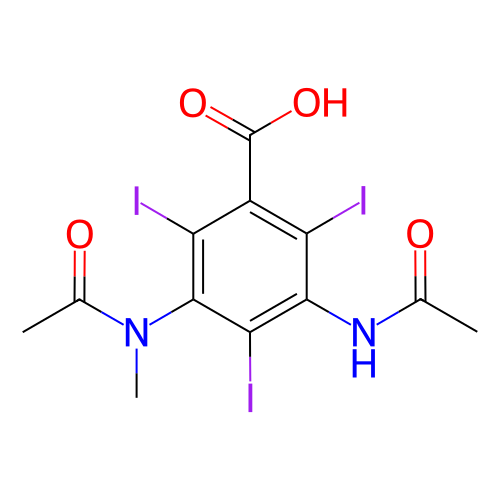

In [79]:
from IPython.display import SVG
image = new_client.image
image.set_format("svg")
SVG(image.get('CHEMBL1736'))

In [81]:
# By inchi key (international chemical identifier)
mol = molecule.filter(molecule_structures__standard_inchi_key = "BSYNRYMUTXBXSQ-UHFFFAOYSA-N").only('pref_name')
mol

[{'pref_name': 'ASPIRIN'}]

In [ ]:
# TODO: SMILES similarity / connectivity

### Connection to Diseases

In [88]:
# All approved drugs - first filter
# attention: consider drugs with ongoing trials as well
# TODO: look up to the phase where the safety is established

approved_drugs = molecule.filter(max_phase__gte=1).order_by('molecule_properties__mw_freebase')
len(approved_drugs)

16754

In [98]:
# Drugs approved for a specific disease

drug_indication = new_client.drug_indication

# EFO term - Experimental Factor Ontology
psoriasis_ind = drug_indication.filter(efo_term__icontains="psoriasis")
len(psoriasis_ind)

260

In [99]:
psoriasis_ind[1] # contains MeSH ID as well
                 # indication_refs --> www.clinicaltrials.gov

{'drugind_id': 22632,
 'efo_id': 'EFO:0000676',
 'efo_term': 'psoriasis',
 'indication_refs': [{'ref_id': 'NCT00195676,NCT00235820,NCT00237887,NCT00338754,NCT00513370,NCT00566722,NCT00574249,NCT00645814,NCT00645892,NCT00645905,NCT00646191,NCT00647400,NCT00735787,NCT00927069,NCT00932113,NCT01251614,NCT01265823,NCT01483599,NCT01644396,NCT01646073,NCT01704599,NCT01872546,NCT01899755,NCT01970488,NCT02016105,NCT02016482,NCT02196701,NCT02207231,NCT02207244,NCT02489227,NCT02581345,NCT02660580,NCT02694523,NCT02762955,NCT02850965,NCT03210259,NCT03217734,NCT03316781,NCT03412747,NCT03849404,NCT03927352,NCT04453137,NCT05073315,NCT05495568,NCT05510063,NCT05683054,NCT06005532',
   'ref_type': 'ClinicalTrials',
   'ref_url': 'https://clinicaltrials.gov/search?term=NCT00195676%20NCT00235820%20NCT00237887%20NCT00338754%20NCT00513370%20NCT00566722%20NCT00574249%20NCT00645814%20NCT00645892%20NCT00645905%20NCT00646191%20NCT00647400%20NCT00735787%20NCT00927069%20NCT00932113%20NCT01251614%20NCT01265823%20NC

In [ ]:
psoriasis_mols = molecule.filter(
    molecule_chembl_id__in=[ drug['molecule_chembl_id'] for drug in psoriasis_ind]
)
len(psoriasis_mols) # NOTE: not all found for some reason

217

In [ ]:
# Filter drugs by approval year
drug = new_client.drug 
len(drug.filter(first_approval__gte=2024)) # NOTE: use it for timestamps

45

In [ ]:
# Hm, shares some attributes with molecule
set(mols[0].keys()).intersection(set(drug[0].keys()))


{'availability_type',
 'biotherapeutic',
 'black_box_warning',
 'chirality',
 'first_approval',
 'first_in_class',
 'helm_notation',
 'max_phase',
 'molecule_chembl_id',
 'molecule_properties',
 'molecule_structures',
 'molecule_synonyms',
 'oral',
 'parenteral',
 'prodrug',
 'topical',
 'usan_stem',
 'usan_stem_definition',
 'usan_year',
 'withdrawn_flag'}

### Other Molecule Characteristics

In [122]:
# Biotherapeutic molecules - antibodies, growth factors
# NOTE: many are not approved

bioth = molecule.filter(biotherapeutic__isnull=False)
len(bioth)

23921

In [ ]:
# Filter molecules by name / mol. weight
molecule.filter(molecule_properties__mw_freebase__lte=300, pref_name__iendswith="nib").only(['molecule_chembl_id', 'pref_name'])

[{'molecule_chembl_id': 'CHEMBL276711', 'pref_name': 'SEMAXANIB'}, {'molecule_chembl_id': 'CHEMBL4085457', 'pref_name': 'RITLECITINIB'}, {'molecule_chembl_id': 'CHEMBL4594348', 'pref_name': 'ELSUBRUTINIB'}]

In [125]:
# Rule of five - whether drug can be potentially orally bioavaliable
molecule.filter(molecule_properties__num_ro5_violations=0)

[{'atc_classifications': [], 'availability_type': -1, 'biotherapeutic': None, 'black_box_warning': 0, 'chemical_probe': 0, 'chirality': -1, 'cross_references': [], 'dosed_ingredient': False, 'first_approval': None, 'first_in_class': -1, 'helm_notation': None, 'inorganic_flag': -1, 'max_phase': None, 'molecule_chembl_id': 'CHEMBL6329', 'molecule_hierarchy': {'active_chembl_id': 'CHEMBL6329', 'molecule_chembl_id': 'CHEMBL6329', 'parent_chembl_id': 'CHEMBL6329'}, 'molecule_properties': {'alogp': '2.11', 'aromatic_rings': 3, 'full_molformula': 'C17H12ClN3O3', 'full_mwt': '341.75', 'hba': 5, 'hbd': 1, 'heavy_atoms': 24, 'mw_freebase': '341.75', 'np_likeness_score': '-1.56', 'num_ro5_violations': 0, 'psa': '84.82', 'qed_weighted': '0.74', 'ro3_pass': 'N', 'rtb': 3}, 'molecule_structures': {'canonical_smiles': 'Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl', 'molfile': '\n     RDKit          2D\n\n 24 26  0  0  0  0  0  0  0  0999 V2000\n    5.2792   -2.0500    0.0000 C   0  0  0  0  0  0  0  

### Targets / Activity

In [ ]:
# Activity (IC50) towards a target
# TODO: assay types
# TODO: pChEMBL value - way to standardize assays
# TODO: target genes
target = new_client.target
activity = new_client.activity

TypeError: 

In [130]:
herg

[]